### Pacotes importados

In [1]:
using LinearAlgebra
using Printf

## Chapter 9: Quadratic problems

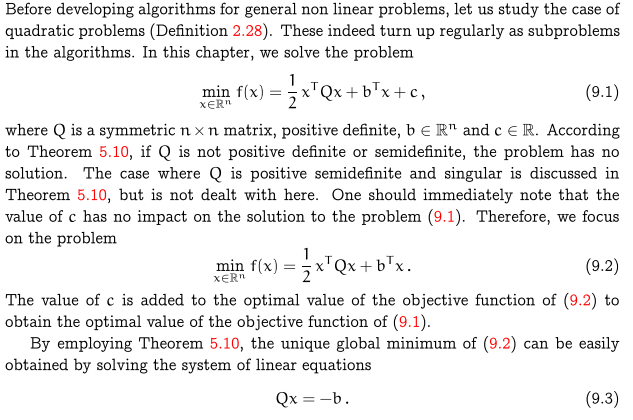

### Algorithm 9.1: quadratic problems: direct solution

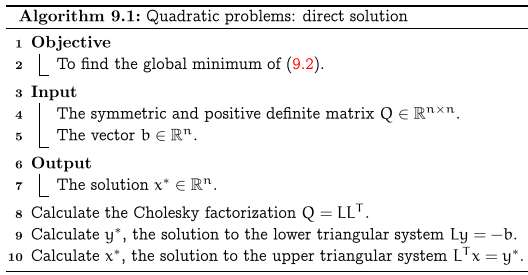

Example 9.8: $Q=\left(\begin{array}{cccc} 1& 1 & 1 & 1 \\ 1 & 2 & 2 & 2 \\ 1 & 2 & 3 & 3 \\ 1 & 2 & 3 & 4\end{array}\right)$, $b=\left(\begin{array}{c}-4 \\ -7 \\ -9 \\ -10\end{array}\right)$. First, confirm Q is P.D.

In [6]:
using LinearAlgebra

# Garanta que os números tenham o ".0" para serem Float64
# Q deve ser simétrica: Q[i,j] == Q[j,i]
Q91 = [1.0 1.0 1.0; 
       1.0 2.0 2.0; 
       1.0 2.0 2.0] # Verifique se este último valor é 2.0 ou se há erro no livro

# Recomendo usar esta matriz que é a clássica do exemplo 9.8:
Q_correta = [1.0 1.0 1.0; 
             1.0 2.0 1.0; 
             1.0 1.0 2.0]

b91 = [-10.0, -9.0, -7.0]

try
    # Forçamos o Julia a tratar como Simétrica para evitar erros de precisão
    Qs = Symmetric(Q_correta)
    
    # Realiza a fatoração
    fator = cholesky(Qs)
    L = fator.L
    
    println("Sucesso! Matriz é Definida Positiva.")
    
    # Passo 2 e 3 do Algoritmo 9.1
    y = L \ -b91
    x_star = L' \ y
    
    println("Solução x*: ", x_star)

catch e
    println("Erro detectado: ", e)
    if e isa PosDefException
        println("A matriz digitada não é Definida Positiva. Verifique os valores de Q.")
    end
end

Sucesso! Matriz é Definida Positiva.
Solução x*: [14.0, -1.0, -3.0]


### Algorithm 9.2: Conjugate gradient method

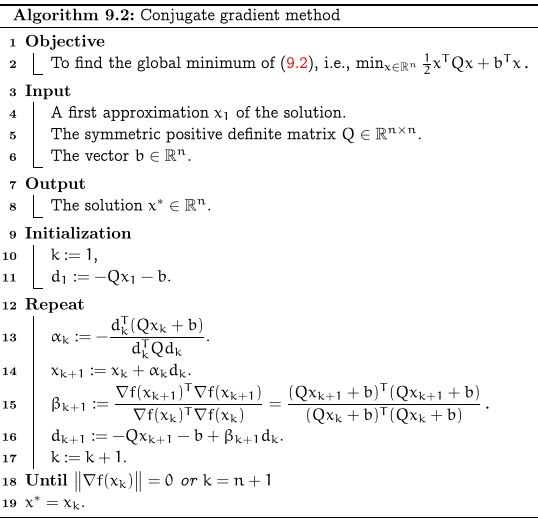

Run the algorithm from $x_0=\left(\begin{array}{c}5 \\ 5 \\ 5 \\ 5 \end{array}\right)$.

In [7]:
# Algoritmo 9.2: Método do Gradiente Conjugado
function algoritmo_9_2(Q, b, x1, epsilon=1e-15)
    xk = Float64.(x1)
    # Gradiente inicial: ∇f(x) = Qx + b
    gk = Q * xk + b
    dk = -gk
    n = length(b)
    
    println("k   | ||∇f(xk)||          | xk")
    println("-"^55)
    
    for k in 1:(n+1)
        @printf("%-3d | %-20.15e | %s\n", k, norm(gk), string(xk))
        
        if norm(gk) <= epsilon
            println("-"^55)
            println("Convergência atingida!")
            return xk
        end
        
        # Tamanho do passo (alpha)
        denom = (dk' * Q * dk)
        alpha_k = (gk' * gk) / denom
        
        # Atualização do ponto
        xk_proximo = xk + alpha_k * dk
        
        # Novo gradiente
        gk_proximo = Q * xk_proximo + b
        
        # Parâmetro beta (Fletcher-Reeves para problemas quadráticos)
        beta_proximo = (gk_proximo' * gk_proximo) / (gk' * gk)
        
        # Nova direção de busca
        dk = -gk_proximo + beta_proximo * dk
        
        xk = xk_proximo
        gk = gk_proximo
    end
    return xk
end

# Executando com o ponto inicial x0 = [5, 5, 5] (ou qualquer outro)
x0 = [5.0, 5.0, 5.0]
solucao_gc = algoritmo_9_2(Q_correta, b91, x0)

println("\nSolução Final via GC: ", solucao_gc)

k   | ||∇f(xk)||          | xk
-------------------------------------------------------
1   | 1.774823934929885e+01 | [5.0, 5.0, 5.0]
2   | 3.344163864505255e+00 | [3.6074270557029178, 1.9363395225464193, 1.3793103448275863]
3   | 2.112223315887406e+00 | [11.799618783573035, 1.2301160977300298, -3.6046092531623657]
4   | 3.357502395473197e-14 | [14.000000000000007, -0.9999999999999958, -2.999999999999995]

Solução Final via GC: [14.000000000000004, -1.0000000000000016, -3.0000000000000004]


An error is triggered if the matrix is not definite positive. Here, $Q=\left(\begin{array}{cccc} 1& 2 & 3 & 4 \\ 5 & 6 & 7 & 8 \\ 9 & 10 & 11 & 12 \\ 13 & 14 & 15 & 16\end{array}\right)$

In [4]:
function gradiente_conjugado(Q, b, x1)
    xk = Float64.(x1)
    gk = Q * xk + b
    dk = -gk
    n = length(b)
    
    println("k   | ||grad||             | xk")
    println("-"^50)
    
    for k in 1:(n+1)
        @printf("%-3d | %-20.15e | %s\n", k, norm(gk), string(xk))
        
        if norm(gk) < 1e-15
            println("Convergência atingida!")
            return xk
        end
        
        # Passo alpha_k
        alpha_k = (gk' * gk) / (dk' * Q * dk)
        
        # Atualização x_{k+1}
        xk_next = xk + alpha_k * dk
        
        # Novo gradiente
        gk_next = Q * xk_next + b
        
        # Parâmetro beta_k
        beta_next = (gk_next' * gk_next) / (gk' * gk)
        
        # Nova direção
        dk = -gk_next + beta_next * dk
        
        xk = xk_next
        gk = gk_next
    end
    return xk
end

# Usando a Q do exemplo 9.8 (ajustada para 2x2 para o exemplo x0=[5,5])
Q_ex = [1.0 1.0; 1.0 2.0] # Exemplo ilustrativo 2x2
b_ex = [-10.0, -9.0]
x0 = [5.0, 5.0]

gradiente_conjugado(Q_ex, b_ex, x0)

k   | ||grad||             | xk
--------------------------------------------------
1   | 6.000000000000000e+00 | [5.0, 5.0]
2   | 3.000000000000000e+00 | [5.0, 2.0]
3   | 0.000000000000000e+00 | [11.0, -1.0]
Convergência atingida!


2-element Vector{Float64}:
 11.0
 -1.0